In [1]:
# silly autoreload to avoid restarting the kernel every time
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from ekf_vindy.vindy import torch_config
from scipy.integrate import odeint
from ekf_vindy.plotting import plotter
from ekf_vindy.ekf.utils import add_noise_with_snr
from ekf_vindy.ekf.filters.config import DynamicsConfig
from ekf_vindy.ekf.filters.ekf import EKF
from scipy.integrate import odeint

seed = 29

# Setup torch device and dtype

np.random.seed(seed)

LaTeX is installed. Using LaTeX for rendering.


In [2]:
torch_config.setup_device_and_type()

PyTorch device set to cpu and dtype set to torch.float32.


# Roessler ODE with VINDy

We will use the varional version of SINDy to learn the following dynamical system:

$$
\begin{align}
\dot{z}_0 &= -z_1 - z_2, \\
\dot{z}_1 &= z_0 + a z_1, \\
\dot{z}_2 &= b + z_2 (z_0 - c),
\end{align}
$$

where $ a = 0.2, b = 0.2, c = 5.7$. Notice that in the first equation we will learn the coefficients $1$ as well. Let's define the vector field and generate training data.

In [3]:
def roessler(x, t, params):
    a = params['a']
    b = params['b']
    c = params['c']
    
    x, y, z =  x[0], x[1], x[2]
    return [-y - z, x + a * y, b + z * (x - c)]

We load the trained VINDy model from before (see other notebook).

In [4]:
import torch
from ekf_vindy.vindy.layers.vindy_layer import VINDyLayer

vindy_layer = VINDyLayer(latent_dim=3,
                         n_parameters=0,
                         poly_order=2,
                         parameter_names=None,
                         prior_loc=0.0,
                         prior_scale=1.0)

path = "../../weights/roessler/roessler_vindy_weights"
ckpt = torch.load(path + ".pt", map_location=torch_config.device)
vindy_layer.big_xi.data = ckpt["big_xi"]
vindy_layer.big_xi_log_scales.data = ckpt["big_xi_log_scales"]
vindy_layer.mask.data = ckpt["mask"]

vindy_layer.print_mean_system()

/home/carlos/.cache/pypoetry/virtualenvs/vindy-MoRRIXoN-py3.11/lib/python3.11/site-packages/pysindy/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


(z_0)' = -0.997 z_1 + -0.97 z_2
(z_1)' = 0.993 z_0 + 0.2 z_1
(z_2)' = 0.18 1 + -5.64 z_2 + 0.992 z_0 z_2


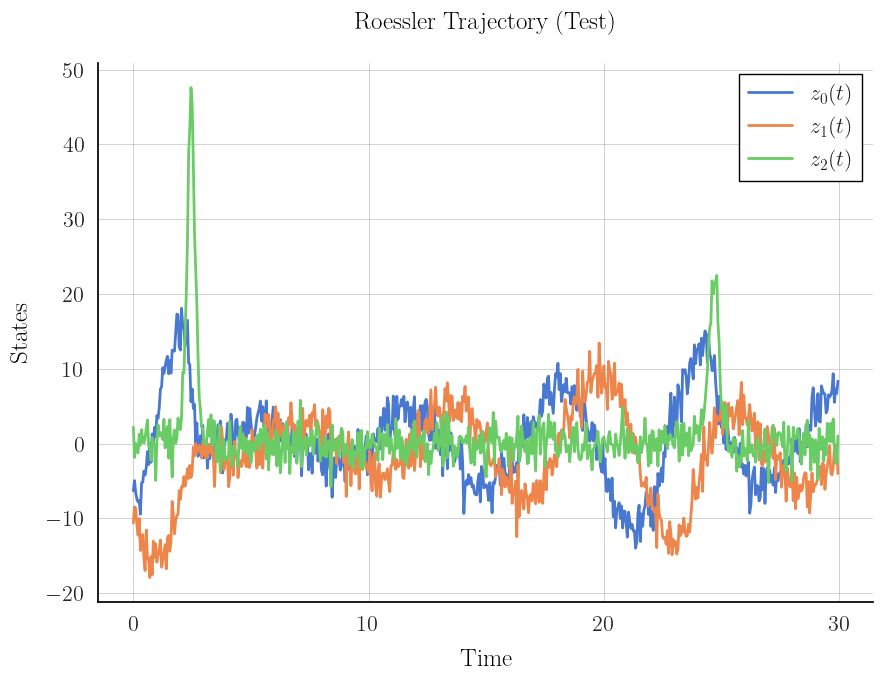

In [26]:
params = {
    'a': 0.2,
    'b': 0.2,
    'c': 8.0
}

mean_ic = np.array([-10, -10, 2])
std = 1
dt = 0.05
time_instances = np.arange(0, 30, dt)
x0_test = np.random.randn(1, 3) * std + mean_ic
x_test = odeint(roessler, x0_test[0, :], time_instances, args=(params,))
x_test = add_noise_with_snr(x_test, snr=10)

fig, ax = plotter.plot_trajectory(x_test, time_instances, title='Roessler Trajectory (Test)', xlabel='Time', ylabel='States',
                                   state_names=["$z_0(t)$", "$z_1(t)$", "$z_2(t)$"], x_tick_skip=10)

plt.show()

Let's run a filter with the VINDy initialization!

Just fetch the Laplace prior in and compute the Gaussians that minimize the KL divergence (closed-form minimizer)

(z_0)' = -0.997 z_1 + -0.97 z_2
(z_1)' = 0.993 z_0 + 0.2 z_1
(z_2)' = 0.18 1 + -5.64 z_2 + 0.992 z_0 z_2
[1, z_0, z_1, z_2, z_0**2, z_0*z_1, z_0*z_2, z_1**2, z_1*z_2, z_2**2]
variance_diag: [0.00016899 0.00105553 0.00100475]


Processing: 100%|██████████| 599/599 [00:00<00:00, 1036.69it/s]


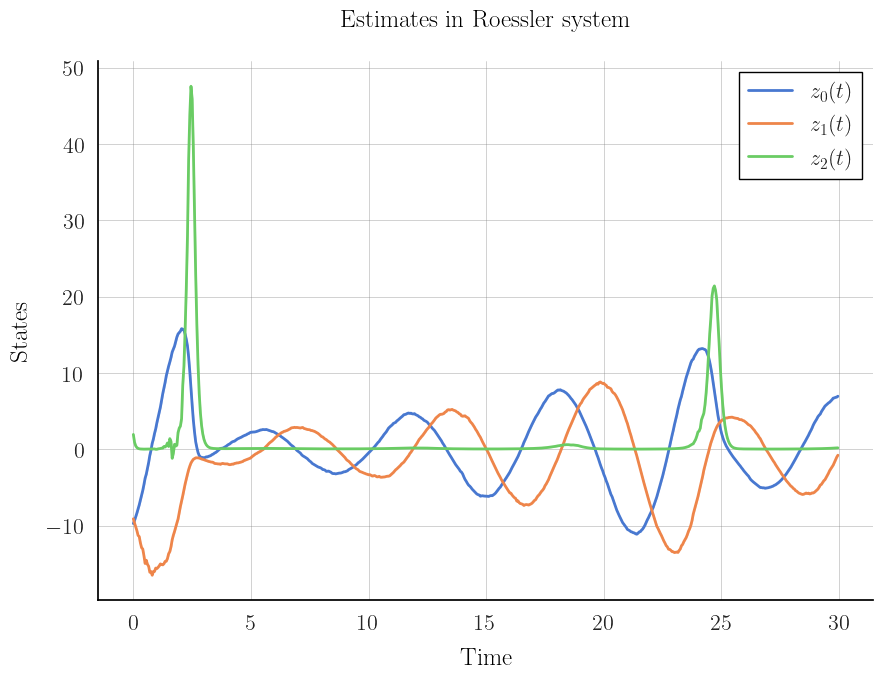

In [ ]:
from ekf_vindy.plotting import plotter
from ekf_vindy.ekf.filters.ekf import EKF
from ekf_vindy.ekf.utils import scale_to_var_optimal, extract_tracked_entries

# Fetch all library terms, coefficients (masked with zeros), and the variances of the coefficients.
library_terms = vindy_layer.get_feature_names()
coeffs = vindy_layer.coefficients()
variables = vindy_layer.get_variable_names()
# TODO: This is correct I think. You 
variances = scale_to_var_optimal(vindy_layer.get_scales(masked=True))
vindy_layer.print_mean_system(masked=True)

print(vindy_layer.library_symbols)
# tracked_terms = [[2, 3],
#                  [1, 2],
#                  [0, 3, 6]]
# we track only a, b and c
tracked_terms = [[],
                 [2],
                 [0, 3]]
variance_diag = extract_tracked_entries(variances, tracked_terms)
print(f'variance_diag: {variance_diag}')

""" 
The first 3 entries of the vectorized state covariance matrix express our uncertainty about the dynamical system's initial state. 
So it is not model uncertainty, this must be set manually.
"""
p0_flat = np.array([1e-6, 1e-6, 1e-6])
p0 = np.diag(np.concatenate([p0_flat, variance_diag]))
# These are still set manually, and they should be guided by the setting we are in. Such as sensor reliability, or model stationarity.
q = np.diag([1e-6, 1e-6, 1e-6, 1e-6, 1e-6, 1e-6])
r = np.diag([4e-3, 4e-3, 4e-3])

x0 = x0_test[0, :]
config = DynamicsConfig(variables, library_terms, tracked_terms, coeffs, q , r)
filter = EKF(x0, p0, config=config, integration_rule='RK4')
dts = np.diff(time_instances)

filter.run_filter(dts, x_test[1:, :])

filter_estimates = filter.states.xcal_states[:, :3]
sdevs = filter.states.sdev_states[:, :3]

fig, x = plotter.plot_trajectory(filter_estimates, time_instances, sdevs, x_tick_skip=5, title='Estimates in Roessler system', xlabel='Time', ylabel='States',
                                 state_names=["$z_0(t)$", "$z_1(t)$", "$z_2(t)$"])#, ylim=[-70, 70])